# Predictive Modeling with Linear Regression Project: ReCell

## Problem Statement

### Business Context

Buying and selling used phones and tablets used to be something that happened on a handful of online marketplace sites. But the used and refurbished device market has grown considerably over the past decade, and a new IDC (International Data Corporation) forecast predicts that the used phone market would be worth \$52.7bn by 2023 with a compound annual growth rate (CAGR) of 13.6% from 2018 to 2023. This growth can be attributed to an uptick in demand for used phones and tablets that offer considerable savings compared with new models.

Refurbished and used devices continue to provide cost-effective alternatives to both consumers and businesses that are looking to save money when purchasing one. There are plenty of other benefits associated with the used device market. Used and refurbished devices can be sold with warranties and can also be insured with proof of purchase. Third-party vendors/platforms, such as Verizon, Amazon, etc., provide attractive offers to customers for refurbished devices. Maximizing the longevity of devices through second-hand trade also reduces their environmental impact and helps in recycling and reducing waste. The impact of the COVID-19 outbreak may further boost this segment as consumers cut back on discretionary spending and buy phones and tablets only for immediate needs.

### Objective

The rising potential of this comparatively under-the-radar market fuels the need for an ML-based solution to develop a dynamic pricing strategy for used and refurbished devices. ReCell, a startup aiming to tap the potential in this market, has hired you as a data scientist. They want you to analyze the data provided and build a linear regression model to predict the price of a used phone/tablet and identify factors that significantly influence it.

### Data Description

The data contains the different attributes of used/refurbished phones and tablets. The data was collected in the year 2021. The detailed data dictionary is given below.


- brand_name: Name of manufacturing brand
- os: OS on which the device runs
- screen_size: Size of the screen in cm
- 4g: Whether 4G is available or not
- 5g: Whether 5G is available or not
- main_camera_mp: Resolution of the rear camera in megapixels
- selfie_camera_mp: Resolution of the front camera in megapixels
- int_memory: Amount of internal memory (ROM) in GB
- ram: Amount of RAM in GB
- battery: Energy capacity of the device battery in mAh
- weight: Weight of the device in grams
- release_year: Year when the device model was released
- days_used: Number of days the used/refurbished device has been used
- normalized_new_price: Normalized price of a new device of the same model in euros
- normalized_used_price: Normalized price of the used/refurbished device in euros

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 -q --user

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
# !pip install scikit-learn==1.2.2 seaborn==0.11.1 matplotlib==3.3.4 numpy==1.24.3 pandas==1.5.2 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
# Importing Necessary Libraries
#Libraries used for reading and Manipulating data
import pandas as pd 
import numpy as np
# Libraries used for visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split # used for splitting data into train and test
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # used to check model performance
import statsmodels.api as sm # used to build linear regression model



## Loading the dataset

In [3]:
Recell_data= pd.read_csv("used_device_data.csv")
Recell_data.head()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837


## Data Overview

- Observations
- Sanity checks

In [4]:
Recell_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand_name             3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   main_camera_mp         3275 non-null   float64
 6   selfie_camera_mp       3452 non-null   float64
 7   int_memory             3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   float64
dtypes: f

#### Observation

The ReCell dataset contains 3,454 observations and 15 variables.It includes 9 float, 2 integer, and 4 categorical (object) variables. Missing values are present in several numerical columns, including main_camera_mp, selfie_camera_mp, int_memory, ram, battery, and weight, while the categorical variables contain no missing values.

In [10]:
Recell_data.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand_name,3454,34,Others,502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
os,3454,4,Android,3214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
screen_size,3454.0,NaN,NaN,NaN,13.713115,3.80528,5.08,12.7,12.83,15.34,30.71
4g,3454,2,yes,2335,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5g,3454,2,no,3302,NaN,NaN,NaN,NaN,NaN,NaN,NaN
main_camera_mp,3275.0,NaN,NaN,NaN,9.460208,4.815461,0.08,5.0,8.0,13.0,48.0
selfie_camera_mp,3452.0,NaN,NaN,NaN,6.554229,6.970372,0.0,2.0,5.0,8.0,32.0
int_memory,3450.0,NaN,NaN,NaN,54.573099,84.972371,0.01,16.0,32.0,64.0,1024.0
ram,3450.0,NaN,NaN,NaN,4.036122,1.365105,0.02,4.0,4.0,4.0,12.0
battery,3448.0,NaN,NaN,NaN,3133.402697,1299.682844,500.0,2100.0,3000.0,4000.0,9720.0


#### Observation

The descriptive statistics show that the dataset contains 3,454 mobile devices with a mix of categorical and numerical features. There are 34 different brands represented, with "Others" being the most frequent category, while Android is the dominant operating system. Most devices support 4G, whereas relatively few support 5G, reflecting the release period of the phones.

Among the numerical variables, devices have an average screen size of 13.71 inches, 4 GB of RAM, 54.57 GB of internal storage, 3,133 mAh battery capacity, and 183 g average weight. The devices were released between 2013 and 2020, with an average release year of 2016, and have been used for an average of approximately 675 days.

The normalized new price has a higher average (5.23) than the normalized used price (4.36), which is expected since used devices are generally sold at lower prices. Several variables, including internal memory, battery capacity, weight, and camera resolution, exhibit large ranges and relatively high standard deviations, indicating considerable variability and the possible presence of outliers. Additionally, a few variables contain a small number of missing values, but the dataset is largely complete.

In [11]:
# Checks for missing values
Recell_data.isnull().sum()

brand_name                 0
os                         0
screen_size                0
4g                         0
5g                         0
main_camera_mp           179
selfie_camera_mp           2
int_memory                 4
ram                        4
battery                    6
weight                     7
release_year               0
days_used                  0
normalized_used_price      0
normalized_new_price       0
dtype: int64

#### Observation

Most variables have no missing values, indicating that the dataset is generally of good quality.
* The main_camera_mp feature has the highest number of missing values (179), accounting for approximately 5.2% of the dataset.
* The remaining variables—selfie_camera_mp (2), int_memory (4), ram (4), battery (6), and weight (7)—contain very few missing values.
  
Since the proportion of missing values is low overall, appropriate imputation techniques can be applied instead of dropping the affected records, thereby preserving most of the available data.

In [13]:
# Duplicate records
Recell_data.duplicated().sum()

0

The ReCell dataset contains no duplicate records, indicating that each observation is unique and no duplicate entries need to be removed before analysis.

### Univariant Analysis 


In [15]:
# Separate Numerical and Categorical columns
num_cols = Recell_data.select_dtypes(include=np.number).columns

cat_cols = Recell_data.select_dtypes(include='object').columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['screen_size', 'main_camera_mp', 'selfie_camera_mp', 'int_memory',
       'ram', 'battery', 'weight', 'release_year', 'days_used',
       'normalized_used_price', 'normalized_new_price'],
      dtype='object')

Categorical Columns:
Index(['brand_name', 'os', '4g', '5g'], dtype='object')


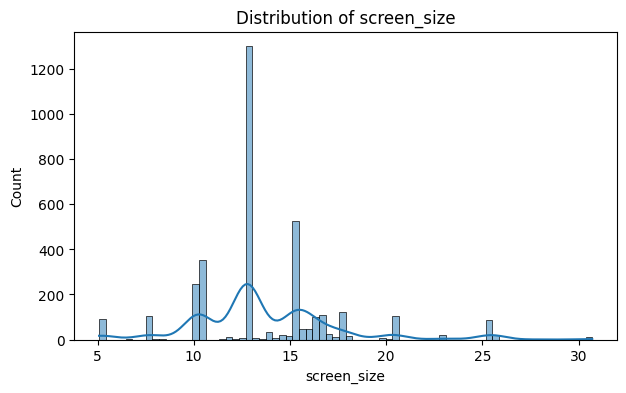

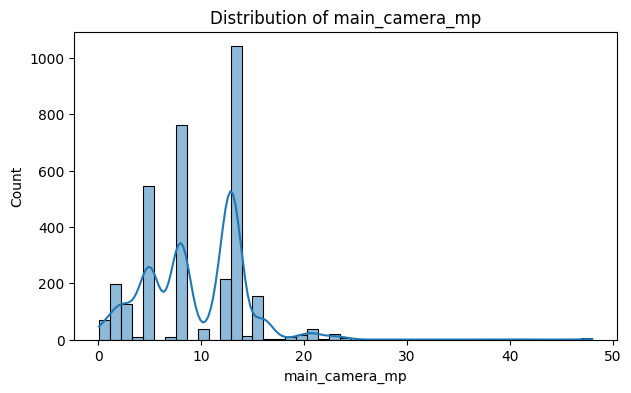

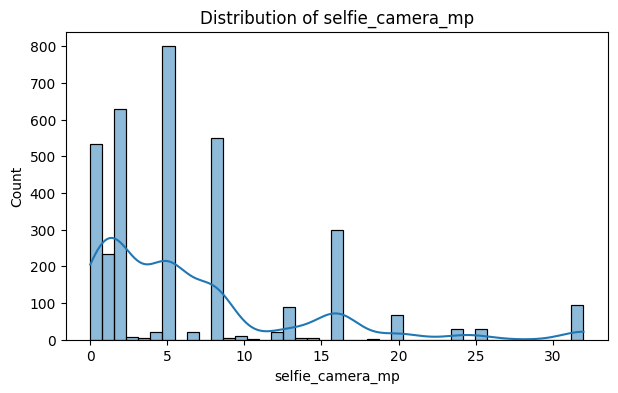

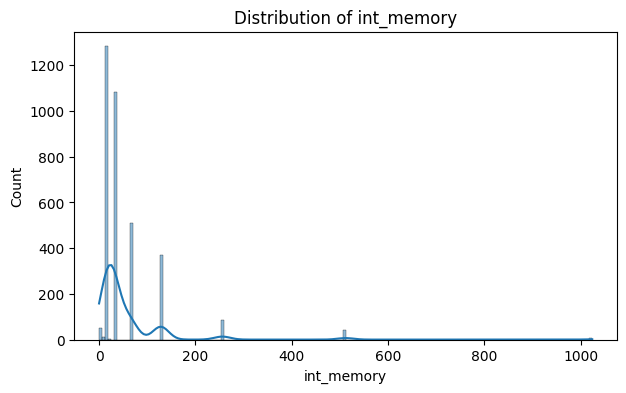

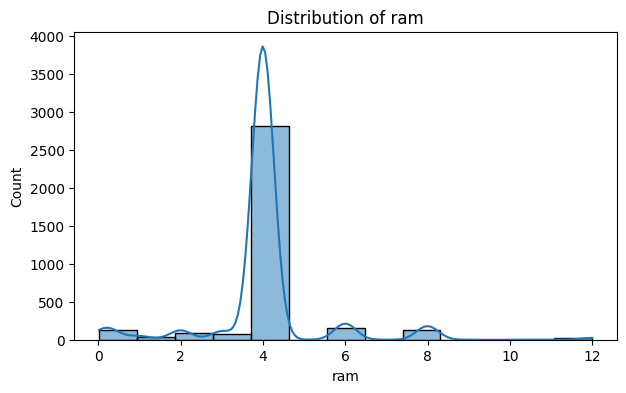

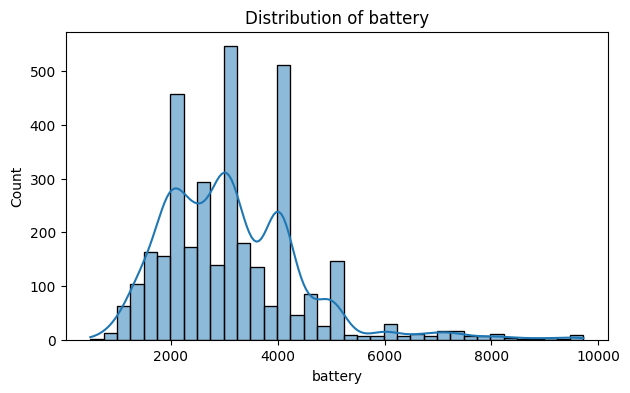

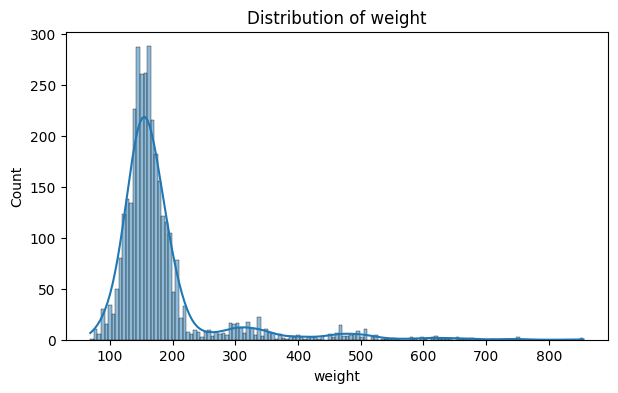

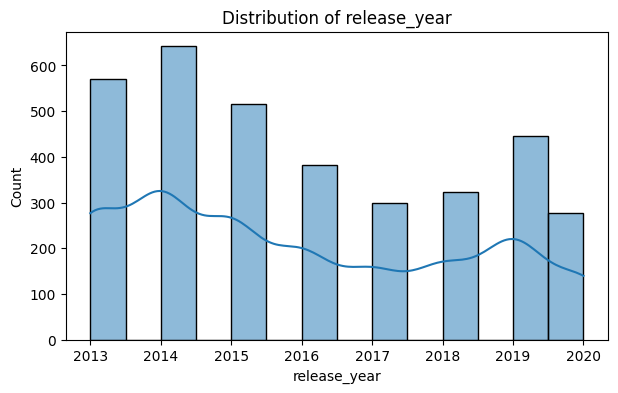

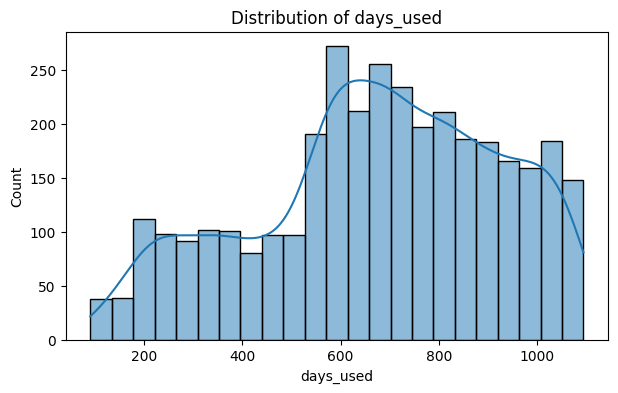

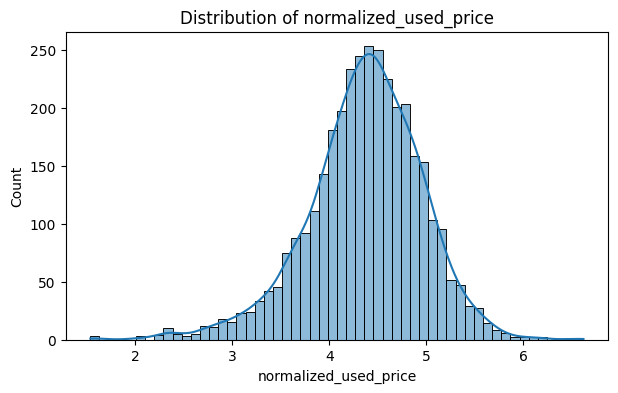

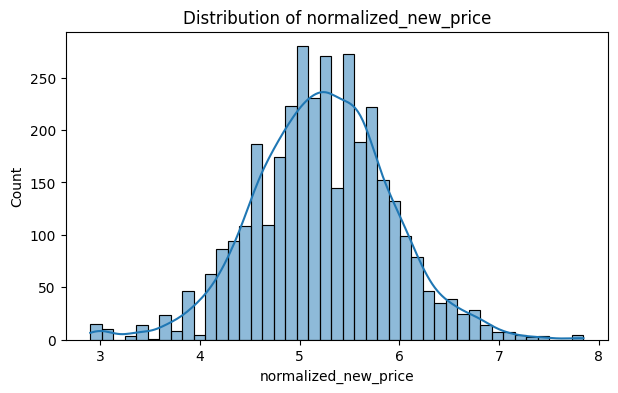

In [17]:
# Distribution of Numerical Variables
for col in num_cols:
    plt.figure(figsize=(7,4))

    sns.histplot(Recell_data[col], kde=True)

    plt.title(f'Distribution of {col}')

    plt.xlabel(col)

    plt.show()

#### Observations from the Doistribution of Numerical Variables


#### 1. `screen_size`
- The distribution is multimodal, with the highest concentration around 12–15 inches.
- Most devices have screen sizes between 10 and 16 inches.
- A few devices have much larger screens (above 20 inches), suggesting tablets or potential outliers.

#### 2. `main_camera_mp`
- The distribution is right-skewed.
- Most devices have rear camera resolutions between 5 MP and 13 MP, with 13 MP being the most common.
- A small number of devices have very high resolutions (20–48 MP), indicating possible outliers.

#### 3. `selfie_camera_mp`
- The distribution is positively skewed.
- Most devices have front camera resolutions between 2 MP and 8 MP.
- Only a few devices have high-resolution selfie cameras (above 16 MP), resulting in a long right tail.

#### 4. `int_memory`
- The distribution is highly right-skewed.
- Most devices have storage capacities of 16 GB, 32 GB, or 64 GB.
- A small number of premium devices have 256 GB, 512 GB, or 1024 GB of storage, creating extreme outliers.

#### 5. `ram`
- The distribution is concentrated around 4 GB, which is the most common RAM configuration.
- The distribution is not symmetric, as relatively few devices have 6 GB, 8 GB, or 12 GB RAM.
- Very few devices have RAM below 2 GB or above 8 GB.

#### 6. `battery`
- The distribution is moderately right-skewed.
- Most devices have battery capacities between 2,000 and 4,000 mAh.
- A few devices have exceptionally large batteries (above 6,000 mAh), which appear as outliers.

#### 7. `weight`
- Most devices weigh between 120 g and 200 g, with the highest concentration around 150–180 g.
- The distribution is positively skewed.
- A few very heavy devices (above 300 g) create a long right tail and are likely tablets or rugged devices.

#### 8. `release_year`
- The dataset contains devices released between 2013 and 2020.
- More devices were released during 2013–2015, while relatively fewer were released between 2016 and 2018.
- A reasonable number of newer devices from 2019–2020 are also included.

#### 9. `days_used`
- The distribution is slightly left-skewed (negatively skewed).
- Most devices have been used between 550 and 900 days.
- Relatively few devices have very low usage periods (below 300 days).

#### 10. `normalized_used_price`
- The distribution is approximately bell-shaped (close to normal).
- Most values are concentrated around 4.3–4.6.
- Only a few devices have extremely low or high normalized used prices.

#### 11. `normalized_new_price`
- The distribution is approximately normal.
- Most values are concentrated around 5.0–5.6.
- Relatively few devices are found at the lower and higher ends of the price range.

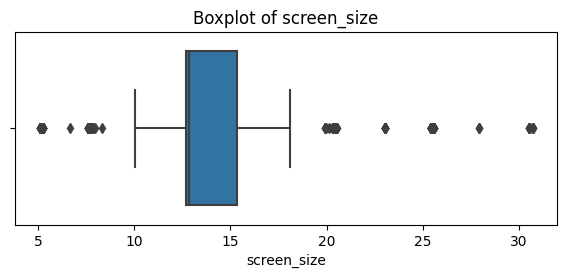

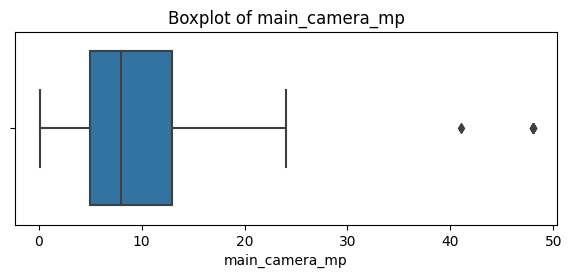

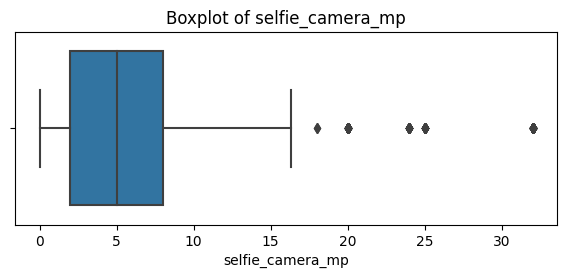

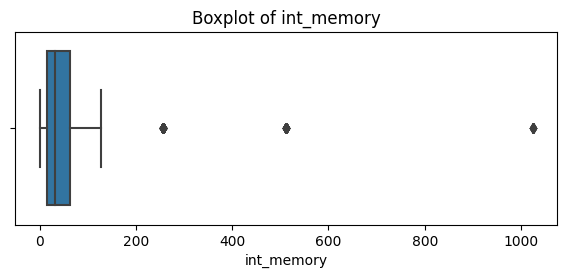

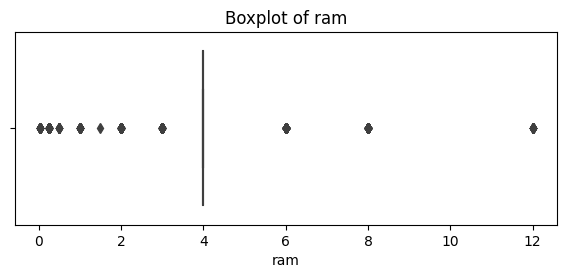

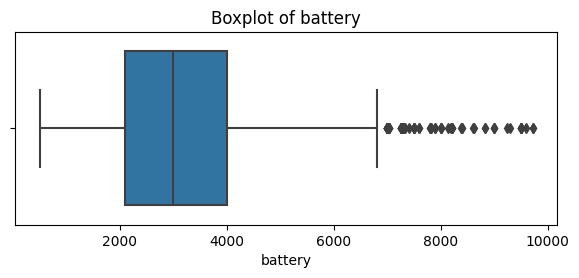

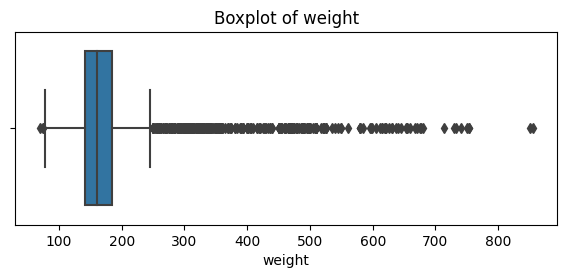

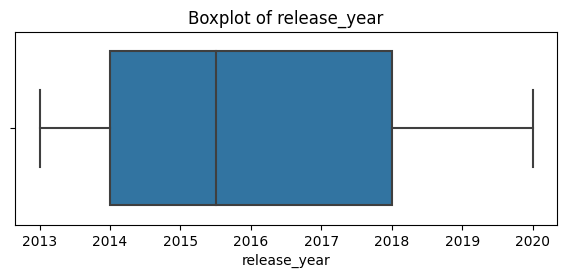

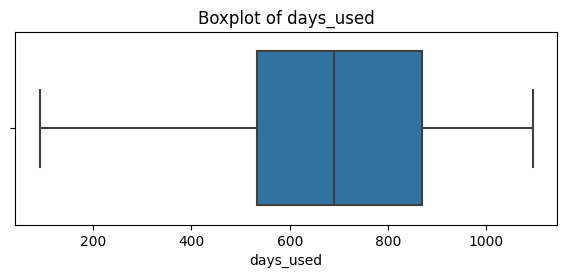

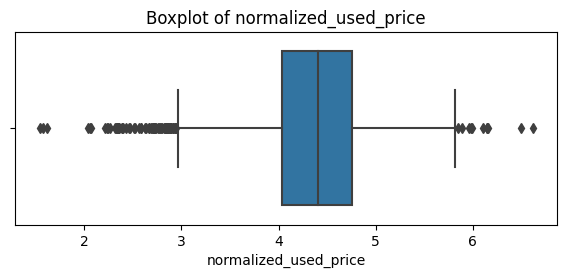

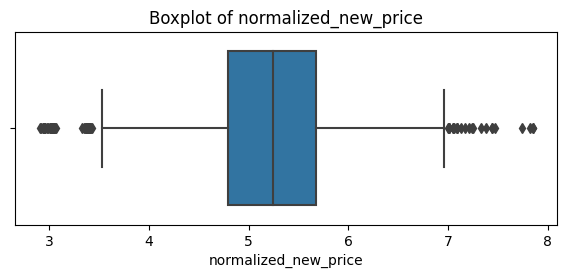

In [19]:
# Box Plot for Numerical Variables - To check Outliers

for col in num_cols:
    plt.figure(figsize=(7,2.5))

    sns.boxplot(x=Recell_data[col])

    plt.title(f'Boxplot of {col}')

    plt.show()


## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What does the distribution of normalized used device prices look like?
2. What percentage of the used device market is dominated by Android devices?
3. The amount of RAM is important for the smooth functioning of a device. How does the amount of RAM vary with the brand?
4. A large battery often increases a device's weight, making it feel uncomfortable in the hands. How does the weight vary for phones and tablets offering large batteries (more than 4500 mAh)?
5. Bigger screens are desirable for entertainment purposes as they offer a better viewing experience. How many phones and tablets are available across different brands with a screen size larger than 6 inches?
6. A lot of devices nowadays offer great selfie cameras, allowing us to capture our favorite moments with loved ones. What is the distribution of devices offering greater than 8MP selfie cameras across brands?
7. Which attributes are highly correlated with the normalized price of a used device?

## Data Preprocessing

- Missing value treatment
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

## EDA

- It is a good idea to explore the data once again after manipulating it.

## Model Building - Linear Regression

## Model Performance Check

## Checking Linear Regression Assumptions

- In order to make statistical inferences from a linear regression model, it is important to ensure that the assumptions of linear regression are satisfied.

## Final Model

## Actionable Insights and Recommendations

-


___